# Classifying Air Quality Index Levels Based on Pollutant Concentrations in Philippine Urban Environments Using Support Vector Machine, LightGBM, CatBoost, and Multilayer Perceptron Neural Network

**Course:** CSELEC2C

**Section:** 3CSC

Group 4

**Group Members:**
*   Baron, Hans S.
*   Duran, Vincent G.
*   Eva, Kyle Francis E.
*   Rodelas, Raymond J.  

**Project Type:** Machine Learning Final Project  

## Notebook Description

This notebook implements the machine learning pipeline for classifying Air Quality Index (AQI) levels in Philippine urban environments using the **PH Philippine Cities Air Quality Index Data 2025** dataset. The dataset contains pollutant concentration features such as CO, NO, NO₂, O₃, SO₂, PM2.5, PM10, and NH₃, along with temporal and city-based variables.

The target variable, `main.aqi`, is treated as an ordinal multiclass label representing AQI severity levels. The notebook covers dataset consolidation, preprocessing, feature preparation, stratified train-validation-test splitting, model training, hyperparameter tuning, and evaluation.

The models implemented in this study are:

- Support Vector Machine
- LightGBM Classifier
- CatBoost Classifier
- Multilayer Perceptron Neural Network

Model performance was evaluated using precision, recall, F1-score, macro F1-score, confusion matrix analysis, and accuracy as a supplementary metric.

# Part 1: Dataset Import and Preprocessing

This section includes downloading the dataset from Kaggle, merging, and cleaning it in preparation for model training

In [ ]:
# ============================================================
# 1.1 Install and Import Required Libraries
# ============================================================

import os
import glob
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
# ============================================================
# 1.2 Download Dataset from Kaggle
# ============================================================
!pip install -q kagglehub
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download(
    "bwandowando/philippine-cities-air-quality-index-data-2025"
)

dataset_path = Path(path)

print("Path to dataset files:", dataset_path)

100%|██████████| 21.4M/21.4M [00:00<00:00, 131MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429


In [ ]:
# ============================================================
# 1.3 Locate and Combine Monthly CSV Files
# ============================================================

import pandas as pd
from pathlib import Path

dataset_path = Path("/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429")

# Keep only actual files, not directories
combined_files = [
    p for p in dataset_path.rglob("*CombinedData.csv")
    if p.is_file()
]

# Sort by month/file name
combined_files = sorted(combined_files)

print(f"Found {len(combined_files)} actual CombinedData CSV files:")
for file in combined_files:
    print(file)

dataframes = []

for file in combined_files:
    temp_df = pd.read_csv(file)

    # Example parent path:
    # .../202501/202501_CombinedData.csv/202501_CombinedData.csv
    source_month = file.parts[-3]  # gets 202501, 202502, etc.

    temp_df["source_file"] = file.name
    temp_df["source_month"] = source_month

    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", df.shape)
display(df.head())

print("Source months:")
print(sorted(df["source_month"].unique()))

print("\nRows per month:")
display(df["source_month"].value_counts().sort_index())

Found 12 actual CombinedData CSV files:
/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429/202501/202501_CombinedData.csv/202501_CombinedData.csv
/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429/202502/202502_CombinedData.csv/202502_CombinedData.csv
/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429/202503/202503_CombinedData.csv/202503_CombinedData.csv
/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429/202504/202504_CombinedData.csv/202504_CombinedData.csv
/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429/202505/202505_CombinedData.csv/202505_CombinedData.csv
/root/.cache/kagglehub/datasets/bwandowando/philippine-cities-air-quality-index-data-2025/versions/429/202506/202506_CombinedData.csv/202506_CombinedData.csv
/root/.cache

,datetime,main.aqi,components.co,components.no,components.no2,components.o3,components.so2,components.pm2_5,components.pm10,components.nh3,city_name,source_file,source_month
0,2025-01-01 00:00:00+08:00,2.0,367.17,0.00,2.10,67.95,0.80,13.40,15.15,1.95,Alaminos,202501_CombinedData.csv,202501
1,2025-01-01 00:00:03+08:00,2.0,594.14,0.05,11.82,11.44,2.12,14.98,19.22,4.02,Angeles City,202501_CombinedData.csv,202501
2,2025-01-01 00:00:05+08:00,1.0,327.11,0.00,3.13,32.90,0.51,5.38,6.57,1.69,Antipolo,202501_CombinedData.csv,202501
3,2025-01-01 00:00:06+08:00,1.0,208.62,0.00,1.15,37.91,2.74,3.25,3.49,0.25,Bacolod,202501_CombinedData.csv,202501
4,2025-01-01 00:00:09+08:00,3.0,1588.82,11.40,50.72,0.00,30.52,46.08,69.62,9.63,Bacoor,202501_CombinedData.csv,202501


Source months:
['202501', '202502', '202503', '202504', '202505', '202506', '202507', '202508', '202509', '202510', '202511', '202512']

Rows per month:


,count
source_month,
202501,51608
202502,53380
202503,102599
202504,99343
202505,102624
202506,99295
202507,99634
202508,102671
202509,99358


In [ ]:
# ============================================================
# 1.4 Inspect Combined Dataset Structure
# ============================================================

print("Combined dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

print("\nMissing values per column:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nAQI class distribution:")
display(df["main.aqi"].value_counts().sort_index())

Combined dataset shape: (1115195, 13)

Columns:
['datetime', 'main.aqi', 'components.co', 'components.no', 'components.no2', 'components.o3', 'components.so2', 'components.pm2_5', 'components.pm10', 'components.nh3', 'city_name', 'source_file', 'source_month']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115195 entries, 0 to 1115194
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   datetime          1115195 non-null  object 
 1   main.aqi          1115195 non-null  float64
 2   components.co     1115195 non-null  float64
 3   components.no     1115195 non-null  float64
 4   components.no2    1115195 non-null  float64
 5   components.o3     1115195 non-null  float64
 6   components.so2    1115195 non-null  float64
 7   components.pm2_5  1115195 non-null  float64
 8   components.pm10   1115195 non-null  float64
 9   components.nh3    1115195 non-null  float64
 10  city_name         

,0
datetime,0
main.aqi,0
components.co,0
components.no,0
components.no2,0
components.o3,0
components.so2,0
components.pm2_5,0
components.pm10,0
components.nh3,0



Duplicate rows:
0

AQI class distribution:


,count
main.aqi,
1.000,779425
1.111,2
1.222,10
1.333,4
1.444,5
1.556,1
1.667,5
1.778,2
2.000,276826


In [ ]:
# ============================================================
# 1.5 Clean Target Variable: Keep Valid AQI Classes Only
# ============================================================

# Check original unique target values
print("Original unique main.aqi values:")
print(sorted(df["main.aqi"].unique()))

# Keep only valid AQI class labels: 1, 2, 3, 4, 5
valid_aqi_classes = [1.0, 2.0, 3.0, 4.0, 5.0]

before = df.shape[0]
df = df[df["main.aqi"].isin(valid_aqi_classes)].copy()
after = df.shape[0]

print(f"Removed {before - after} rows with non-integer/invalid AQI labels.")
print("Current dataset shape:", df.shape)

# Convert target to integer
df["main.aqi"] = df["main.aqi"].astype(int)

print("\nCleaned AQI class distribution:")
class_distribution = pd.DataFrame({
    "count": df["main.aqi"].value_counts().sort_index(),
    "percentage": (df["main.aqi"].value_counts(normalize=True).sort_index() * 100).round(2)
})

display(class_distribution)

Original unique main.aqi values:
[np.float64(1.0), np.float64(1.111), np.float64(1.222), np.float64(1.333), np.float64(1.444), np.float64(1.556), np.float64(1.667), np.float64(1.778), np.float64(2.0), np.float64(2.222), np.float64(2.333), np.float64(2.556), np.float64(2.667), np.float64(2.778), np.float64(2.889), np.float64(3.0), np.float64(3.111), np.float64(3.333), np.float64(3.667), np.float64(3.889), np.float64(4.0), np.float64(5.0)]
Removed 43 rows with non-integer/invalid AQI labels.
Current dataset shape: (1115152, 13)

Cleaned AQI class distribution:


,count,percentage
main.aqi,,
1,779425,69.89
2,276826,24.82
3,50856,4.56
4,5335,0.48
5,2710,0.24


In [ ]:
# ============================================================
# 1.6 Standardize Column Names
# ============================================================

rename_map = {
    "main.aqi": "main_aqi",
    "components.co": "co",
    "components.no": "no",
    "components.no2": "no2",
    "components.o3": "o3",
    "components.so2": "so2",
    "components.pm2_5": "pm2_5",
    "components.pm10": "pm10",
    "components.nh3": "nh3"
}

df = df.rename(columns=rename_map)

print("Updated columns:")
print(df.columns.tolist())

display(df.head())

Updated columns:
['datetime', 'main_aqi', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'city_name', 'source_file', 'source_month']


,datetime,main_aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,city_name,source_file,source_month
0,2025-01-01 00:00:00+08:00,2,367.17,0.00,2.10,67.95,0.80,13.40,15.15,1.95,Alaminos,202501_CombinedData.csv,202501
1,2025-01-01 00:00:03+08:00,2,594.14,0.05,11.82,11.44,2.12,14.98,19.22,4.02,Angeles City,202501_CombinedData.csv,202501
2,2025-01-01 00:00:05+08:00,1,327.11,0.00,3.13,32.90,0.51,5.38,6.57,1.69,Antipolo,202501_CombinedData.csv,202501
3,2025-01-01 00:00:06+08:00,1,208.62,0.00,1.15,37.91,2.74,3.25,3.49,0.25,Bacolod,202501_CombinedData.csv,202501
4,2025-01-01 00:00:09+08:00,3,1588.82,11.40,50.72,0.00,30.52,46.08,69.62,9.63,Bacoor,202501_CombinedData.csv,202501


In [ ]:
# ============================================================
# 1.7 Convert Datetime and Extract Temporal Features
# ============================================================

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Remove rows where datetime parsing failed, if any
before = df.shape[0]
df = df.dropna(subset=["datetime"]).copy()
after = df.shape[0]

print(f"Removed {before - after} rows with invalid datetime values.")

# Extract simple temporal features
df["month"] = df["datetime"].dt.month
df["day_of_week"] = df["datetime"].dt.dayofweek
df["hour"] = df["datetime"].dt.hour

display(df[["datetime", "month", "day_of_week", "hour"]].head())

Removed 0 rows with invalid datetime values.


,datetime,month,day_of_week,hour
0,2025-01-01 00:00:00+08:00,1,2,0
1,2025-01-01 00:00:03+08:00,1,2,0
2,2025-01-01 00:00:05+08:00,1,2,0
3,2025-01-01 00:00:06+08:00,1,2,0
4,2025-01-01 00:00:09+08:00,1,2,0


In [ ]:
# ============================================================
# 1.8 Define Features and Target
# ============================================================

target_col = "main_aqi"

numeric_features = [
    "co",
    "no",
    "no2",
    "o3",
    "so2",
    "pm2_5",
    "pm10",
    "nh3",
    "month",
    "day_of_week",
    "hour"
]

categorical_features = [
    "city_name"
]

model_df = df[numeric_features + categorical_features + [target_col]].copy()

print("Model dataset shape:", model_df.shape)
display(model_df.head())

Model dataset shape: (1115152, 13)


,co,no,no2,o3,so2,pm2_5,pm10,nh3,month,day_of_week,hour,city_name,main_aqi
0,367.17,0.00,2.10,67.95,0.80,13.40,15.15,1.95,1,2,0,Alaminos,2
1,594.14,0.05,11.82,11.44,2.12,14.98,19.22,4.02,1,2,0,Angeles City,2
2,327.11,0.00,3.13,32.90,0.51,5.38,6.57,1.69,1,2,0,Antipolo,1
3,208.62,0.00,1.15,37.91,2.74,3.25,3.49,0.25,1,2,0,Bacolod,1
4,1588.82,11.40,50.72,0.00,30.52,46.08,69.62,9.63,1,2,0,Bacoor,3


In [ ]:
# ============================================================
# 1.9 Stratified Train-Validation-Test Split
# 70% Train, 15% Validation, 15% Test
# ============================================================

from sklearn.model_selection import train_test_split

X = model_df.drop(columns=["main_aqi"])
y = model_df["main_aqi"]

# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nValidation class distribution:")
display(y_val.value_counts(normalize=True).sort_index().mul(100).round(2))

print("\nTesting class distribution:")
display(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))

Training set: (780606, 12) (780606,)
Validation set: (167273, 12) (167273,)
Testing set: (167273, 12) (167273,)

Training class distribution:


,proportion
main_aqi,
1,69.89
2,24.82
3,4.56
4,0.48
5,0.24



Validation class distribution:


,proportion
main_aqi,
1,69.89
2,24.82
3,4.56
4,0.48
5,0.24



Testing class distribution:


,proportion
main_aqi,
1,69.89
2,24.82
3,4.56
4,0.48
5,0.24


In [ ]:
# ============================================================
# 1.10 Build Preprocessing Pipelines
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "co", "no", "no2", "o3", "so2",
    "pm2_5", "pm10", "nh3",
    "month", "day_of_week", "hour"
]

categorical_features = ["city_name"]

# For SVM and MLP-NN
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# For LightGBM and other tree-based models using one-hot encoding
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# Part 2: Model Training and Hyperparameter Tuning

This section trains and evaluates the machine learning models for AQI level classification. The models include Support Vector Machine as the baseline classifier, followed by LightGBM, CatBoost, and Multilayer Perceptron Neural Network.

In [ ]:
# ============================================================
# 2.1 Import Model Training Libraries
# ============================================================

!pip install -q lightgbm catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2.2 Define Evaluation Function
# ============================================================

results = []

def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluates a multiclass classification model and stores key metrics.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    })

    print(f"===== {model_name} Evaluation =====")
    print(f"Accuracy:        {accuracy:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1-score:  {f1_macro:.4f}")
    print(f"Weighted F1:     {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "accuracy": accuracy,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted
    }

In [ ]:
# ============================================================
# 2.3 Baseline Model: Support Vector Machine
# ============================================================

svm_model = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    ))
])

svm_model.fit(X_train, y_train)

svm_val_pred = svm_model.predict(X_val)

svm_metrics = evaluate_model(
    model_name="Support Vector Machine",
    y_true=y_val,
    y_pred=svm_val_pred
)

===== Support Vector Machine Evaluation =====
Accuracy:        0.8475
Macro Precision: 0.6848
Macro Recall:    0.5668
Macro F1-score:  0.5985
Weighted F1:     0.8446

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.95      0.93    116914
           2       0.74      0.64      0.68     41524
           3       0.41      0.52      0.46      7628
           4       0.45      0.12      0.19       800
           5       0.91      0.61      0.73       407

    accuracy                           0.85    167273
   macro avg       0.68      0.57      0.60    167273
weighted avg       0.85      0.85      0.84    167273



In [ ]:
  # ============================================================
# 2.4 LightGBM Classifier
# ============================================================

lgbm_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", LGBMClassifier(
        objective="multiclass",
        class_weight="balanced",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_val_pred = lgbm_model.predict(X_val)

lgbm_metrics = evaluate_model(
    model_name="LightGBM Classifier",
    y_true=y_val,
    y_pred=lgbm_val_pred
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.207576 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2360
[LightGBM] [Info] Number of data points in the train set: 780606, number of used features: 149
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== LightGBM Classifier Evaluation =====
Accuracy:        0.9965
Macro Precision: 0.9548
Macro Recall:    0.9791
Macro F1-score:  0.9665
Weighted F1:     0.9965

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    116914
           2       1.00      0.99      0.99     41524
           3       0.97      0.98      0.98      7628
           4       0.87      0.95      0.91       800
           5       0.94      0.97      0.95       407

    accuracy                           1.00    167273
   macro avg       0.95      0.98      0.97    167273
weighted avg       1.00      1.00      1.00    167273



In [ ]:
# ============================================================
# 2.5 CatBoost Classifier
# ============================================================

cat_features = ["city_name"]

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=50
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

catboost_val_pred = catboost_model.predict(X_val).flatten()

catboost_metrics = evaluate_model(
    model_name="CatBoost Classifier",
    y_true=y_val,
    y_pred=catboost_val_pred
)

0:	learn: 0.8466905	test: 0.8345567	best: 0.8345567 (0)	total: 8.2s	remaining: 40m 50s
50:	learn: 0.9317473	test: 0.9256985	best: 0.9267603 (43)	total: 3m 36s	remaining: 17m 37s
100:	learn: 0.9467356	test: 0.9377371	best: 0.9377788 (99)	total: 6m 36s	remaining: 13m 1s
150:	learn: 0.9580705	test: 0.9498223	best: 0.9498223 (150)	total: 9m 41s	remaining: 9m 34s
200:	learn: 0.9643213	test: 0.9546916	best: 0.9546916 (200)	total: 12m 33s	remaining: 6m 11s
250:	learn: 0.9701906	test: 0.9599573	best: 0.9602005 (249)	total: 15m 12s	remaining: 2m 58s
299:	learn: 0.9769344	test: 0.9672153	best: 0.9672153 (298)	total: 18m 15s	remaining: 0us

bestTest = 0.9672153169
bestIteration = 298

Shrink model to first 299 iterations.
===== CatBoost Classifier Evaluation =====
Accuracy:        0.9927
Macro Precision: 0.9162
Macro Recall:    0.9672
Macro F1-score:  0.9396
Weighted F1:     0.9928

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00    

In [ ]:
# ============================================================
# 2.6 Results Summary on Validation Set
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,LightGBM Classifier,0.996503,0.954823,0.979120,0.966517,0.996529
2,CatBoost Classifier,0.992665,0.916214,0.967172,0.939596,0.992779
3,CatBoost Classifier,0.992665,0.916214,0.967172,0.939596,0.992779
0,Support Vector Machine,0.847525,0.684840,0.566792,0.598460,0.844588


Best validation model based on Macro F1: LightGBM Classifier


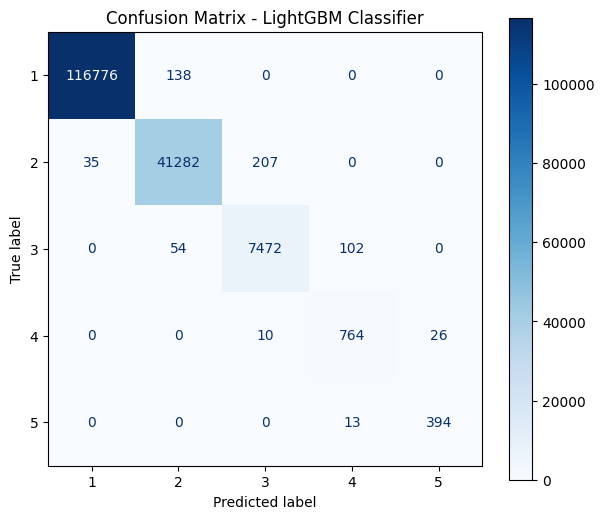

In [ ]:
# ============================================================
# 2.7 Confusion Matrix for Best Validation Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
print("Best validation model based on Macro F1:", best_model_name)

if best_model_name == "Support Vector Machine":
    best_val_pred = svm_val_pred
elif best_model_name == "LightGBM Classifier":
    best_val_pred = lgbm_val_pred
elif best_model_name == "CatBoost Classifier":
    best_val_pred = catboost_val_pred

cm = confusion_matrix(y_val, best_val_pred, labels=sorted(y_val.unique()))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_val.unique())
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [ ]:
# ============================================================
# 2.6 Multilayer Perceptron Neural Network with Adam Optimizer
# ============================================================

!pip install -q tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Fit the scaled preprocessor only on training data
X_train_mlp = scaled_preprocessor.fit_transform(X_train)
X_val_mlp = scaled_preprocessor.transform(X_val)
X_test_mlp = scaled_preprocessor.transform(X_test)

# Convert sparse matrices to dense if needed
if hasattr(X_train_mlp, "toarray"):
    X_train_mlp = X_train_mlp.toarray()
    X_val_mlp = X_val_mlp.toarray()
    X_test_mlp = X_test_mlp.toarray()

print("MLP training shape:", X_train_mlp.shape)
print("MLP validation shape:", X_val_mlp.shape)
print("MLP testing shape:", X_test_mlp.shape)

MLP training shape: (780606, 149)
MLP validation shape: (167273, 149)
MLP testing shape: (167273, 149)


In [ ]:
# Encode labels from 1-5 into 0-4
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: [1 2 3 4 5]
Number of classes: 5


In [ ]:
# ============================================================
# Build MLP-NN Model
# ============================================================

mlp_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_mlp,
    y_train_encoded,
    validation_data=(X_val_mlp, y_val_encoded),
    epochs=50,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.8905 - loss: 0.2774 - val_accuracy: 0.9220 - val_loss: 0.1925
Epoch 2/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.9185 - loss: 0.2010 - val_accuracy: 0.9302 - val_loss: 0.1717
Epoch 3/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9262 - loss: 0.1823 - val_accuracy: 0.9368 - val_loss: 0.1584
Epoch 4/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9300 - loss: 0.1720 - val_accuracy: 0.9395 - val_loss: 0.1493
Epoch 5/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9325 - loss: 0.1656 - val_accuracy: 0.9407 - val_loss: 0.1452
Epoch 6/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9340 - loss: 0.1612 - val_accuracy: 0.9415 - val_loss: 0.1426
Epoch 7/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9356 - loss: 0.1577 - val_accuracy: 0.9412 - val_loss: 0.1410
Epoch 8/50
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9365 - loss: 

In [ ]:
# ============================================================
# Evaluate MLP-NN on Validation Set
# ============================================================

mlp_val_probs = mlp_model.predict(X_val_mlp)
mlp_val_pred_encoded = np.argmax(mlp_val_probs, axis=1)

# Convert back to original labels: 1, 2, 3, 4, 5
mlp_val_pred = label_encoder.inverse_transform(mlp_val_pred_encoded)

mlp_metrics = evaluate_model(
    model_name="MLP Neural Network",
    y_true=y_val,
    y_pred=mlp_val_pred
)

5228/5228 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
===== MLP Neural Network Evaluation =====
Accuracy:        0.9495
Macro Precision: 0.8934
Macro Recall:    0.7955
Macro F1-score:  0.8341
Weighted F1:     0.9491

Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.98      0.97    116914
           2       0.91      0.90      0.90     41524
           3       0.85      0.83      0.84      7628
           4       0.73      0.67      0.70       800
           5       1.00      0.60      0.75       407

    accuracy                           0.95    167273
   macro avg       0.89      0.80      0.83    167273
weighted avg       0.95      0.95      0.95    167273



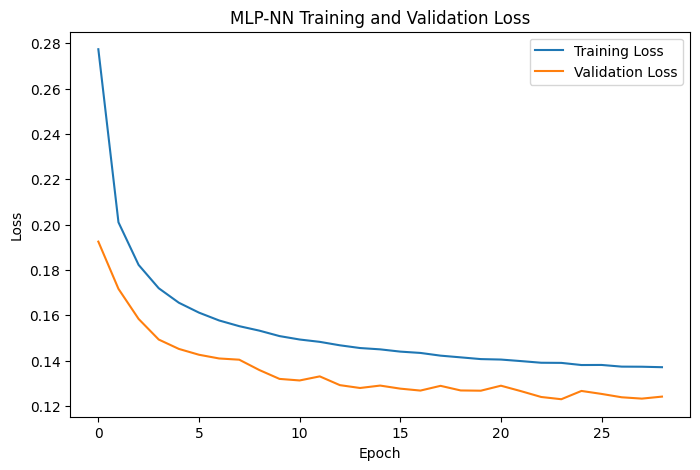

In [ ]:
# ============================================================
# Plot MLP Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP-NN Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Validation Results Summary
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,LightGBM Classifier,0.996503,0.954823,0.979120,0.966517,0.996529
3,CatBoost Classifier,0.992665,0.916214,0.967172,0.939596,0.992779
2,CatBoost Classifier,0.992665,0.916214,0.967172,0.939596,0.992779
4,MLP Neural Network,0.949490,0.893378,0.795493,0.834077,0.949120
0,Support Vector Machine,0.847525,0.684840,0.566792,0.598460,0.844588


# Part 3: Final Test Evaluation and Results Visualization

This section evaluates the trained models on the held-out test set, summarizes final performance, generates confusion matrices, and extracts feature importance where applicable. The test set is used only after model training and validation to provide an unbiased final evaluation.

In [ ]:
# ============================================================
# 3.1 Final Test Evaluation Function
# ============================================================

test_results = []

def evaluate_test_model(model_name, y_true, y_pred):
    """
    Evaluates a model on the test set and stores final metrics.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted
    })

    print(f"===== {model_name} Test Evaluation =====")
    print(f"Accuracy:        {accuracy:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1-score:  {f1_macro:.4f}")
    print(f"Weighted F1:     {f1_weighted:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [ ]:
# ============================================================
# 3.2 Generate Test Predictions
# ============================================================

# SVM test prediction
svm_test_pred = svm_model.predict(X_test)
evaluate_test_model(
    model_name="Support Vector Machine",
    y_true=y_test,
    y_pred=svm_test_pred
)

# LightGBM test prediction
lgbm_test_pred = lgbm_model.predict(X_test)
evaluate_test_model(
    model_name="LightGBM Classifier",
    y_true=y_test,
    y_pred=lgbm_test_pred
)

# CatBoost test prediction
catboost_test_pred = catboost_model.predict(X_test).flatten()
evaluate_test_model(
    model_name="CatBoost Classifier",
    y_true=y_test,
    y_pred=catboost_test_pred
)

# MLP-NN test prediction
mlp_test_probs = mlp_model.predict(X_test_mlp)
mlp_test_pred_encoded = np.argmax(mlp_test_probs, axis=1)
mlp_test_pred = label_encoder.inverse_transform(mlp_test_pred_encoded)

evaluate_test_model(
    model_name="MLP Neural Network",
    y_true=y_test,
    y_pred=mlp_test_pred
)

===== Support Vector Machine Test Evaluation =====
Accuracy:        0.8461
Macro Precision: 0.6853
Macro Recall:    0.5687
Macro F1-score:  0.6010
Weighted F1:     0.8431

Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.95      0.93    116914
           2       0.74      0.63      0.68     41524
           3       0.41      0.51      0.45      7629
           4       0.46      0.13      0.20       800
           5       0.90      0.63      0.74       406

    accuracy                           0.85    167273
   macro avg       0.69      0.57      0.60    167273
weighted avg       0.84      0.85      0.84    167273



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


===== LightGBM Classifier Test Evaluation =====
Accuracy:        0.9970
Macro Precision: 0.9599
Macro Recall:    0.9817
Macro F1-score:  0.9704
Weighted F1:     0.9970

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    116914
           2       1.00      1.00      1.00     41524
           3       0.98      0.98      0.98      7629
           4       0.88      0.96      0.92       800
           5       0.95      0.97      0.96       406

    accuracy                           1.00    167273
   macro avg       0.96      0.98      0.97    167273
weighted avg       1.00      1.00      1.00    167273

===== CatBoost Classifier Test Evaluation =====
Accuracy:        0.9926
Macro Precision: 0.9118
Macro Recall:    0.9591
Macro F1-score:  0.9338
Weighted F1:     0.9927

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00    116914
           2      

In [ ]:
# ============================================================
# 3.3 Final Model Performance Summary
# ============================================================

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(by="Macro F1", ascending=False)

display(test_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,LightGBM Classifier,0.996963,0.959935,0.981668,0.970359,0.996985
2,CatBoost Classifier,0.992623,0.911799,0.959112,0.933838,0.992730
3,MLP Neural Network,0.949269,0.892648,0.801276,0.838077,0.948925
0,Support Vector Machine,0.846144,0.685304,0.568650,0.600974,0.843115


Best test model based on Macro F1: LightGBM Classifier


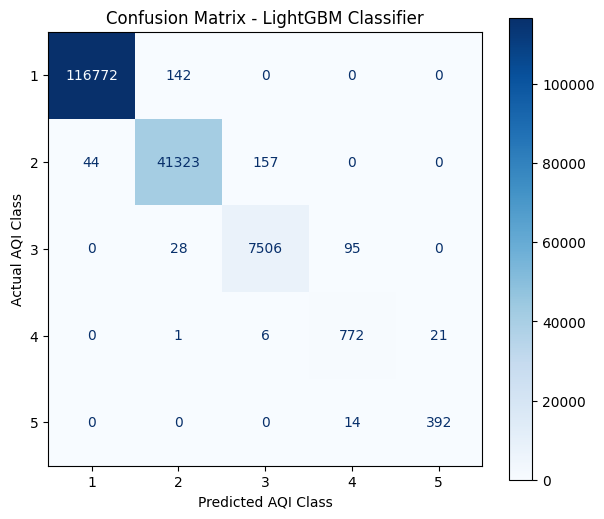

In [ ]:
# ============================================================
# 3.4 Confusion Matrix of the Best Test Model
# ============================================================

best_test_model_name = test_results_df.iloc[0]["Model"]
print("Best test model based on Macro F1:", best_test_model_name)

if best_test_model_name == "Support Vector Machine":
    best_test_pred = svm_test_pred
elif best_test_model_name == "LightGBM Classifier":
    best_test_pred = lgbm_test_pred
elif best_test_model_name == "CatBoost Classifier":
    best_test_pred = catboost_test_pred
elif best_test_model_name == "MLP Neural Network":
    best_test_pred = mlp_test_pred
else:
    raise ValueError("Best model name not recognized.")

labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, best_test_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_test_model_name}")
plt.xlabel("Predicted AQI Class")
plt.ylabel("Actual AQI Class")
plt.show()

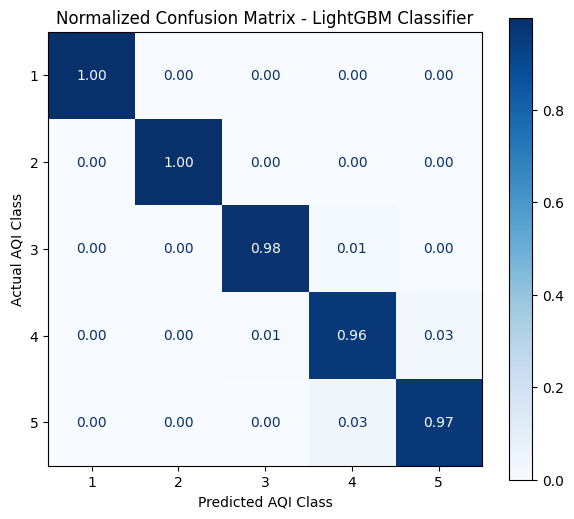

In [ ]:
# ============================================================
# 3.5 Normalized Confusion Matrix
# ============================================================

cm_normalized = confusion_matrix(
    y_test,
    best_test_pred,
    labels=labels,
    normalize="true"
)

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp_norm.plot(ax=ax, cmap="Blues", values_format=".2f")
plt.title(f"Normalized Confusion Matrix - {best_test_model_name}")
plt.xlabel("Predicted AQI Class")
plt.ylabel("Actual AQI Class")
plt.show()

,Feature,Importance
7,nh3,5086
2,no2,4870
0,co,4680
3,o3,4521
4,so2,4482
1,no,4055
5,pm2_5,3837
6,pm10,3715
10,hour,2489
9,day_of_week,1954


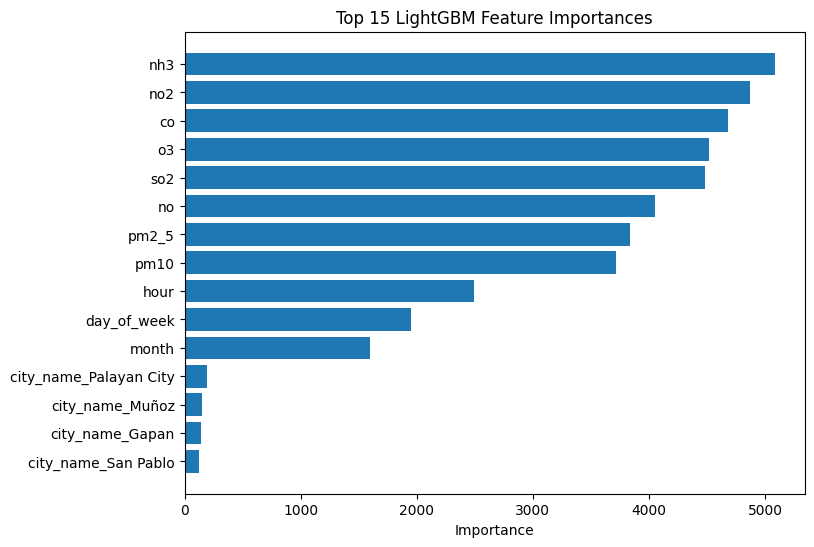

In [ ]:
# ============================================================
# 3.6A LightGBM Feature Importance
# ============================================================

def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    """
    Extracts feature names after ColumnTransformer preprocessing.
    """
    feature_names = []

    # Numeric feature names
    feature_names.extend(numeric_features)

    # One-hot encoded categorical feature names
    cat_pipeline = preprocessor.named_transformers_["cat"]
    onehot = cat_pipeline.named_steps["onehot"]

    cat_feature_names = onehot.get_feature_names_out(categorical_features)
    feature_names.extend(cat_feature_names)

    return feature_names


try:
    lgbm_feature_names = get_feature_names_from_preprocessor(
        tree_preprocessor,
        numeric_features,
        categorical_features
    )

    lgbm_classifier = lgbm_model.named_steps["classifier"]
    lgbm_importances = lgbm_classifier.feature_importances_

    lgbm_importance_df = pd.DataFrame({
        "Feature": lgbm_feature_names,
        "Importance": lgbm_importances
    }).sort_values(by="Importance", ascending=False)

    display(lgbm_importance_df.head(20))

    plt.figure(figsize=(8, 6))
    top_lgbm = lgbm_importance_df.head(15).sort_values(by="Importance")
    plt.barh(top_lgbm["Feature"], top_lgbm["Importance"])
    plt.xlabel("Importance")
    plt.title("Top 15 LightGBM Feature Importances")
    plt.show()

except Exception as e:
    print("Could not generate LightGBM feature importance.")
    print(e)

,Feature,Importance
3,o3,30.289086
5,pm2_5,22.478185
6,pm10,11.115207
11,city_name,6.038387
10,hour,5.656739
9,day_of_week,4.528354
8,month,4.412804
0,co,4.271221
2,no2,4.189901
4,so2,2.473134


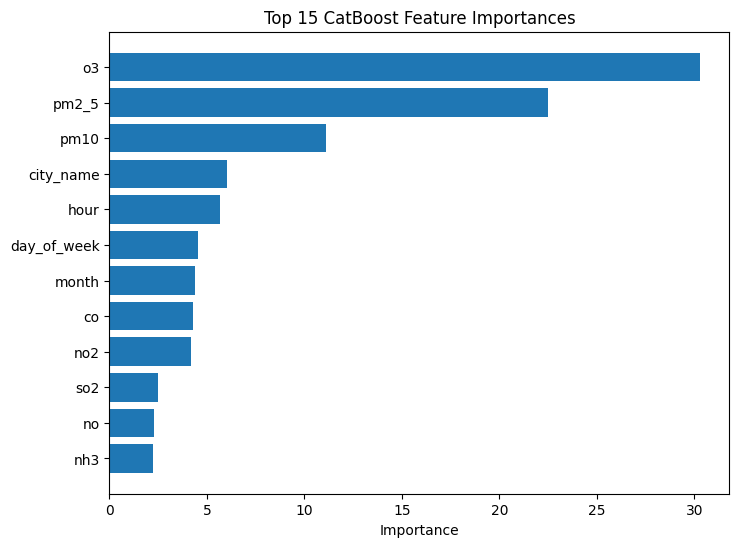

In [ ]:
# ============================================================
# 3.6B CatBoost Feature Importance
# ============================================================

try:
    catboost_importances = catboost_model.get_feature_importance()
    catboost_feature_names = X_train.columns

    catboost_importance_df = pd.DataFrame({
        "Feature": catboost_feature_names,
        "Importance": catboost_importances
    }).sort_values(by="Importance", ascending=False)

    display(catboost_importance_df.head(20))

    plt.figure(figsize=(8, 6))
    top_catboost = catboost_importance_df.head(15).sort_values(by="Importance")
    plt.barh(top_catboost["Feature"], top_catboost["Importance"])
    plt.xlabel("Importance")
    plt.title("Top 15 CatBoost Feature Importances")
    plt.show()

except Exception as e:
    print("Could not generate CatBoost feature importance.")
    print(e)

In [ ]:
# ============================================================
# 3.7 Save Outputs for Manuscript
# ============================================================

from pathlib import Path

output_dir = Path("/content/outputs")
figures_dir = output_dir / "figures"
metrics_dir = output_dir / "metrics"
models_dir = output_dir / "models"

for directory in [output_dir, figures_dir, metrics_dir, models_dir]:
    directory.mkdir(parents=True, exist_ok=True)

# Save final results table
if "test_results_df" in globals():
    test_results_df.to_csv(metrics_dir / "final_model_performance.csv", index=False)
    print("Saved:", metrics_dir / "final_model_performance.csv")
else:
    print("test_results_df not found. Run final test evaluation first.")

# Save feature importance tables if available
if "lgbm_importance_df" in globals():
    lgbm_importance_df.to_csv(metrics_dir / "lightgbm_feature_importance.csv", index=False)
    print("Saved:", metrics_dir / "lightgbm_feature_importance.csv")

if "catboost_importance_df" in globals():
    catboost_importance_df.to_csv(metrics_dir / "catboost_feature_importance.csv", index=False)
    print("Saved:", metrics_dir / "catboost_feature_importance.csv")

print("Outputs saved in:", output_dir)

Saved: /content/outputs/metrics/final_model_performance.csv
Saved: /content/outputs/metrics/lightgbm_feature_importance.csv
Saved: /content/outputs/metrics/catboost_feature_importance.csv
Outputs saved in: /content/outputs


# Supplementary supporting data visualizations

This section includes some important visuals for further analysis and interpretation

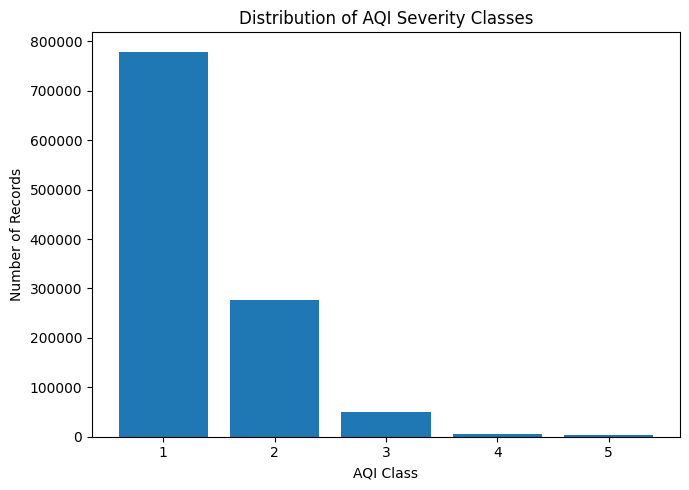

In [ ]:
# AQI Class Distribution

import matplotlib.pyplot as plt

class_counts = model_df["main_aqi"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("AQI Class")
plt.ylabel("Number of Records")
plt.title("Distribution of AQI Severity Classes")
plt.tight_layout()
plt.show()

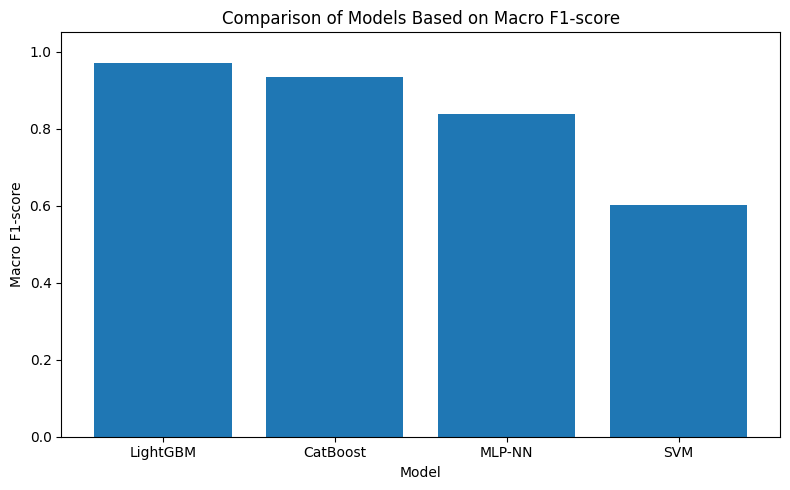

In [ ]:
# Macro F1-score bar chart
import matplotlib.pyplot as plt

models = [
    "LightGBM",
    "CatBoost",
    "MLP-NN",
    "SVM"
]

macro_f1 = [0.9704, 0.9338, 0.8381, 0.6010]

plt.figure(figsize=(8, 5))
plt.bar(models, macro_f1)
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Comparison of Models Based on Macro F1-score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

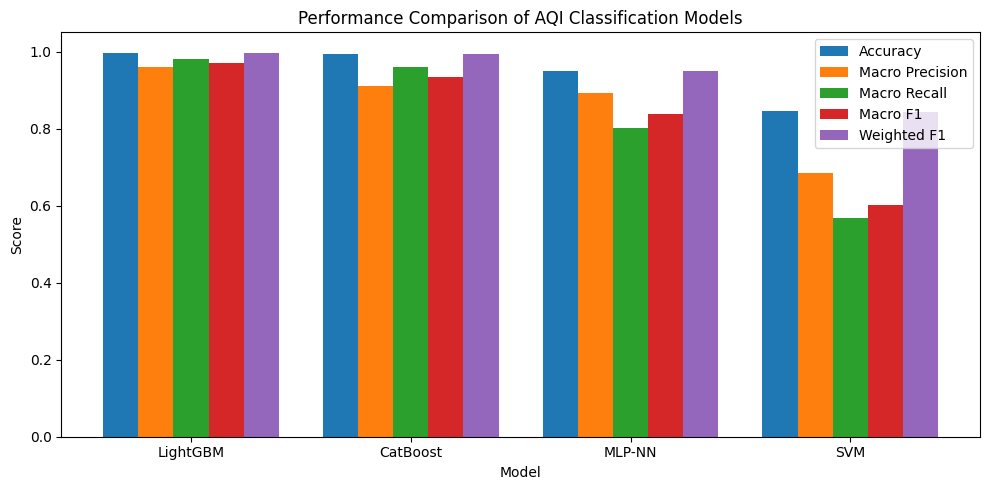

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["LightGBM", "CatBoost", "MLP-NN", "SVM"]
accuracy = [0.9969, 0.9926, 0.9493, 0.8461]
macro_precision = [0.9599, 0.9118, 0.8926, 0.6853]
macro_recall = [0.9817, 0.9591, 0.8013, 0.5687]
macro_f1 = [0.9704, 0.9338, 0.8381, 0.6010]
weighted_f1 = [0.9970, 0.9927, 0.9489, 0.8431]

x = np.arange(len(models))
width = 0.16

plt.figure(figsize=(10, 5))
plt.bar(x - 2*width, accuracy, width, label="Accuracy")
plt.bar(x - width, macro_precision, width, label="Macro Precision")
plt.bar(x, macro_recall, width, label="Macro Recall")
plt.bar(x + width, macro_f1, width, label="Macro F1")
plt.bar(x + 2*width, weighted_f1, width, label="Weighted F1")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Performance Comparison of AQI Classification Models")
plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()